# EDA

**Before building any model, I want to actually understand the data.
Given 5,899 labelled rows. `Col1` to `Col7` are the inputs (columns A-G in the doc brief) and
`ClassificationLabel` (column H) is the thing we have to predict.

My approach is to go column by column, look at what is really
inside each one, catch the data-quality problems early, and for every column write down what
cleaning or feature engineering it needs and *why*. 

## Importing Dependencies


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# make wide tables actually readable in the output instead of getting truncated
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 60)

# for getting consistent styling for every chart below
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Load the data

In [12]:
DATA_PATH = 'Challenge_Data.xlsx'
df = pd.read_excel(DATA_PATH)

print('rows, columns =', df.shape)
df.head(8)

rows, columns = (5899, 8)


,Col1,Col2,Col3,Col4,Col5,Col6,Col7,ClassificationLabel
0,Word1 Word2 Word3 Word4 Word5,44912133,3575.00,Word771 Word772,2018-08-31,Word560 Word561 Word366 Word562,Doc1,Category_1
1,Word6 Word7,10719,1092.50,Word711 Word773 Word774,2018-08-31,Word563 Word366 Word562,NoDoc,Category_2
2,Word8 Word9 Word10 Word11 Word5,4.80Z+11,75.00,Word775 Word776,2018-10-31,Word563 Word564 Word9 Word26,NoDoc,Category_1
3,Word12 Word13 Word7,10731,30980.00,Word777 Word45 Word160 Word45 Word778,2018-01-01,Word565 Word566,NoDoc,Category_1
4,Word8 Word9 Word10 Word11 Word5,4.80F+11,3766.80,Word779 Word258 Word780,2018-01-01,Word567 Word568 Word569 Word570,Doc1,Category_1
5,Word14 Word15,KBNZGNNWMA072618,1898.83,Word613 Word781 Word782,2018-08-31,Word571 Word52 Word572 Word573 Word574,NoDoc,Category_1
6,Word16 Word17 Word18 Word7,WE1243,135.00,Word783 Word784 Word785,2018-09-30,Word563 Word564 Word9 Word26,NoDoc,Category_1
7,Word19 Word20 Word21 Word22 Word23 Word5,20136,184.31,Word575 Word786,2018-11-30,Word563 Word575,NoDoc,Category_2


In [ ]:
# checking the structure and data types of the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5899 entries, 0 to 5898
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Col1                 5899 non-null   str           
 1   Col2                 5899 non-null   object        
 2   Col3                 5899 non-null   float64       
 3   Col4                 5746 non-null   str           
 4   Col5                 5899 non-null   datetime64[us]
 5   Col6                 5899 non-null   str           
 6   Col7                 5899 non-null   str           
 7   ClassificationLabel  5899 non-null   str           
dtypes: datetime64[us](1), float64(1), object(1), str(5)
memory usage: 887.3+ KB


**Observation**

- `Col1` - short text made of `WordN` tokens. Looks categorical (a description/type field).
- `Col2` - Some values are plain numbers, some look like corrupted scientific notation (`4.80Z+11`), some are alphanumeric codes.
- `Col3` - a real float64 number. This looks like one genuine numeric feature.
- `Col4` - text tokens again, and this has some missing values.
- `Col5` - a datetime column.
- `Col6` - text tokens again, looks categorical.
- `Col7` - short codes like `Doc1` / `NoDoc`. Clean and categorical.
- `ClassificationLabel` - the target


## Checking Missing values


In [14]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
Col1,0,0.00
Col2,0,0.00
Col3,0,0.00
Col4,153,2.59
Col5,0,0.00
Col6,0,0.00
Col7,0,0.00
ClassificationLabel,0,0.00


In [34]:
# only Col4 has gaps (153 rows, ~2.6%). before deciding what to do, I want to know if those
# missing rows are random or if they cluster in a particular class / doc type. if the missingness
# itself carries signal, dropping the rows would throw away information.
missing_col4 = df[df['Col4'].isna()]
print('rows missing Col4:', len(missing_col4))
print()
print('label split INSIDE the missing rows (count + %):')
inside = pd.DataFrame({
    'count': missing_col4['ClassificationLabel'].value_counts(),
    'pct': (missing_col4['ClassificationLabel'].value_counts(normalize=True) * 100).round(1),
})
print(inside)
print()
print('label split for the WHOLE dataset (count + %):')
whole = pd.DataFrame({
    'count': df['ClassificationLabel'].value_counts(),
    'pct': (df['ClassificationLabel'].value_counts(normalize=True) * 100).round(1),
})
print(whole)
print()
print('Col7 split inside the missing rows:')
print(missing_col4['Col7'].value_counts())


rows missing Col4: 153

label split INSIDE the missing rows (count + %):
                     count   pct
ClassificationLabel             
Category_1             140  91.5
Category_2              12   7.8
Category2                1   0.7

label split for the WHOLE dataset (count + %):
                     count   pct
ClassificationLabel             
Category_1            5204  88.2
Category_2             627  10.6
Category4               16   0.3
Category_3              12   0.2
category_1              11   0.2
Categry_6               10   0.2
Category 3              10   0.2
Category2                4   0.1
Category_6               2   0.0
Category 5               2   0.0
Category _3              1   0.0

Col7 split inside the missing rows:
Col7
NoDoc    140
Doc1      11
Doc3       1
Doc2       1
Name: count, dtype: int64


**Decision on the 153 missing `Col4` values:** 
- Out of 153 missing rows, 140 (91%) of them belong to `Category_1` and is a `NoDoc` as per `Col7` 
- If this number would have been a substantial amount then it would have caused `TARGET LEAKAGE PROBLEM` where the `Col4` would have got high feature importance whenever the value is missing.

For now, I will keep the rows and fill the blanks with
an explicit `'missing'` token rather than drop them. Two reasons:

1. 153 labelled rows is ~2.6% of the data - and given how rare some classes are, I don't want to
   throw away any labelled examples I don't have to.
2. `Col4` is a text/categorical column, so `'missing'` just becomes its own category. If 'this field
   was blank' happens to be predictive, the model can actually use it. 



## The target column



In [35]:
print('distinct label values as-is:', df['ClassificationLabel'].nunique())
whole = pd.DataFrame({
    'count': df['ClassificationLabel'].value_counts(),
    'pct': (df['ClassificationLabel'].value_counts(normalize=True) * 100).round(1),
})
print(whole)



distinct label values as-is: 11
                     count   pct
ClassificationLabel             
Category_1            5204  88.2
Category_2             627  10.6
Category4               16   0.3
Category_3              12   0.2
category_1              11   0.2
Categry_6               10   0.2
Category 3              10   0.2
Category2                4   0.1
Category_6               2   0.0
Category 5               2   0.0
Category _3              1   0.0


The *same* class is written several different ways:

- casing: `category_1` vs `Category_1`
- spacing: `Category 3`, `Category _3` vs `Category_3`
- missing underscore: `Category4`, `Category2`
- an actual typo: `Categry_6`

If I leave this, the model would treat `Category_1` and `category_1` as two separate classes. So the
first real cleaning job is to normalise all of these down to a single canonical form per category.

In [ ]:
# normalise the label: lowercase, strip spaces/underscores, fix the 'categry' typo, then just
# pull out the category number. this collapses every spelling variant onto Category_<n>.
def clean_label(x):
    s = str(x).strip().lower() ## lowercase all categories
    s = s.replace(' ', '').replace('_', '') ## remove spaces and underscores
    s = s.replace('categry', 'category')      # replace the one genuine typo
    m = re.search('category([0-9]+)', s) ## match 'category' followed by digits
    if m:
        return 'Category_' + m.group(1) ## return the normalized category label
    return 'Unknown' ## return 'Unknown' if no category number is found

df['label'] = df['ClassificationLabel'].apply(clean_label) ## apply the cleaning function to target

# sanity check: show how each raw spelling got mapped, and how many rows each covered
mapping = (df.groupby('ClassificationLabel')
             .agg(mapped_to=('label', 'first'), rows=('label', 'size'))
             .sort_values('rows', ascending=False))
mapping

,mapped_to,rows
ClassificationLabel,,
Category_1,Category_1,5204
Category_2,Category_2,627
Category4,Category_4,16
Category_3,Category_3,12
category_1,Category_1,11
Category 3,Category_3,10
Categry_6,Category_6,10
Category2,Category_2,4
Category 5,Category_5,2


In [ ]:
# did I accidentally map anything to 'Unknown'? if this is 0 we caught every variant.
print('rows that failed to map:', (df['label'] == 'Unknown').sum())

print()

print(pd.DataFrame({
    'count': df['label'].value_counts(),
    'pct': (df['label'].value_counts(normalize=True) * 100).round(1),
}))

rows that failed to map: 0

            count   pct
label                  
Category_1   5215  88.4
Category_2    631  10.7
Category_3     23   0.4
Category_4     16   0.3
Category_6     12   0.2
Category_5      2   0.0


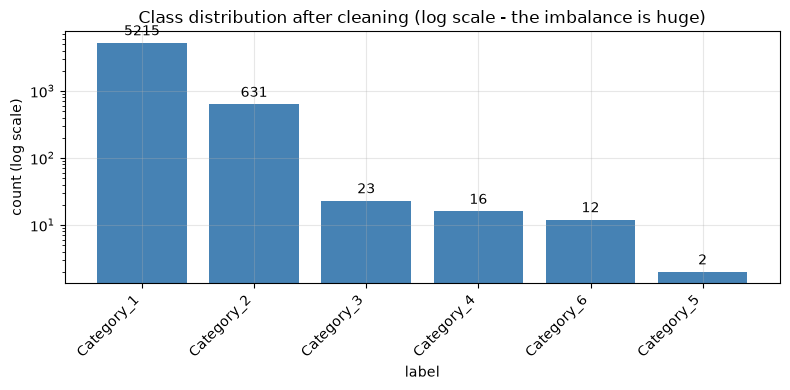

In [19]:
counts = df['label'].value_counts()

fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values, color='steelblue')
# log scale, otherwise Category_1 is so tall the small classes look like zero
ax.set_yscale('log')
ax.set_title('Class distribution after cleaning (log scale - the imbalance is huge)')
ax.set_xlabel('label')
ax.set_ylabel('count (log scale)')
ax.bar_label(bars, padding=3)   # print the real count on top of each bar
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## OBSERVATION:

**this is a severely imbalanced 6-class problem.**

- `Category_1` ~88%, `Category_2` ~11%, and then `Category_3/4/5/6` are tiny (down to `Category_5`
  with just **2 rows** in the entire dataset).

Two consequences I'll carry into modelling:

1. **Accuracy on its own is a trap.** A model that blindly predicts `Category_1` for everything already
   scores ~88%. So I'll judge models on **macro-F1 / balanced accuracy / confusion matrix**, not raw accuracy.
2. **The rare classes can't be split or validated reliably** (we can't stratify 2 rows across train
   /val/test in any meaningful way). 
   At modelling time I'll decide between :
   - using `class_weight` to push the model to care about minorities, and/or 
   - grouping the ultra-rare classes into an
   `Other` bucket and being upfront about the limitation. No feature engineering fixes this - it's a
   labelling/volume issue.

## Go through the feature columns one at a time

For each one: how many distinct values, what do they look like, and what does that imply for
encoding / feature engineering.

### Col1

In [20]:
print('Col1 distinct values:', df['Col1'].nunique())
print()
print('top 10 most common:')
print(df['Col1'].value_counts().head(10))

Col1 distinct values: 313

top 10 most common:
Col1
Word16 Word17 Word18 Word7                                     1245
Word8 Word9 Word10 Word11 Word5                                 323
Word30 Word31                                                   264
Word19 Word20 Word21 Word22 Word23 Word5                        203
Word16 Word17 Word3 Word7                                       198
Word85 Word86 Word87 Word5 Word88 Word16 Word17 Word3 Word7     196
Word33 Word34 Word35 Word7                                      173
Word42 Word43 Word5                                             163
Word38 Word4 Word39                                             161
Word96 Word3 Word4 Word5                                        141
Name: count, dtype: int64


- `Col1` has 313 distinct values . It behaves
like a categorical field. 
- 313 categories is too many to blindly ordinal encode (that
would add 313 sparse columns), so at modelling time I'll ordinal encode with `handle_unknown='ignore'` or use -1 and
lean on the fact that most rows fall into the common values - or cap to the top-N and bucket the
long tail. 

### Col2

In [ ]:
print('Col2 distinct values:', df['Col2'].nunique(), 'out of', len(df), 'rows')
print()
# how many values are clean numbers vs something else?
as_str = df['Col2'].astype(str)
is_numeric = as_str.str.fullmatch(r'-?\d+(\.\d+)?') # check if the string looks like a number
print('numeric-looking:', int(is_numeric.sum()), ' non-numeric/garbled:', int((~is_numeric).sum()))
print()
print('a few of the non-numeric ones:')
print(as_str[~is_numeric].head(10).tolist())

Col2 distinct values: 4818 out of 5899 rows

numeric-looking: 3529  non-numeric/garbled: 2370

a few of the non-numeric ones:
['4.80Z+11', '4.80F+11', 'KBNZGNNWMA072618', 'WE1243', '4.80F+11', '082218-9', '108644-1359', 'JJ1726', 'YP1262', '201811-00046']


`Col2` has ~4,800 distinct values across 5,899 rows - nearly unique per row - and it's a mix of
numbers, alphanumeric codes, and clearly corrupted values like `4.80Z+11` (a number that got mangled
on export). 
    - looks like an ID column with so many unique values so model won't learn anything from it since there is no pattern.

**Decision: drop `Col2`.** An almost-unique ID gives the model nothing to generalise on, and the values are too corrupted to trust.

### Col3 (the numeric one)

In [22]:
print(df['Col3'].describe())
print()
print('skew:', round(df['Col3'].skew(), 2))
print()
print('a spread of quantiles (this exposes the tails):')
print(df['Col3'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
print()
print('negative values:', int((df['Col3'] < 0).sum()))

count    5.899000e+03
mean     1.358787e+05
std      9.301641e+05
min     -2.691116e+05
25%      3.600000e+02
50%      1.093200e+03
75%      4.520040e+03
max      8.799524e+06
Name: Col3, dtype: float64

skew: 8.39

a spread of quantiles (this exposes the tails):
0.01   -4.110917e+03
0.05    5.252000e+01
0.25    3.600000e+02
0.50    1.093200e+03
0.75    4.520040e+03
0.95    6.707970e+04
0.99    2.948604e+06
Name: Col3, dtype: float64

negative values: 69


In [43]:
df['Col3'].value_counts(bins=(-100,-1,0, 10,100,1000,2000,3000,5000,6000),normalize=True)*100
## shows that most of the Col3 values fall within the lower bins, indicating a skewed distribution.

(100.0, 1000.0]     39.142227
(1000.0, 2000.0]    15.205967
(3000.0, 5000.0]     7.645364
(10.0, 100.0]        7.001187
(2000.0, 3000.0]     5.560264
(5000.0, 6000.0]     2.407188
(0.0, 10.0]          0.101712
(-100.001, -1.0]     0.033904
(-1.0, 0.0]          0.033904
Name: proportion, dtype: float64

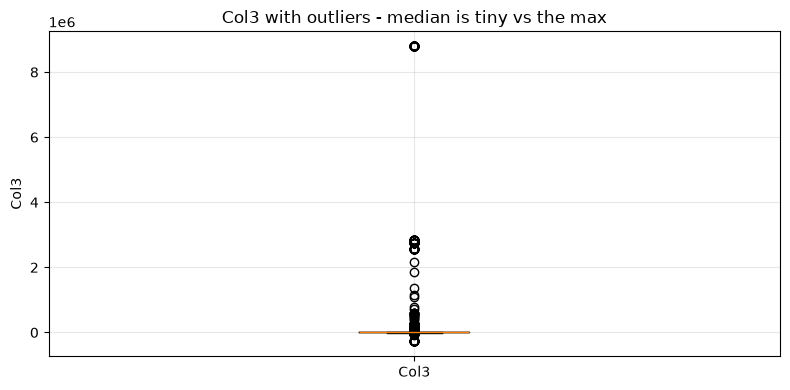

In [24]:
fig, ax = plt.subplots()
ax.boxplot(df['Col3'].dropna())
ax.set_title('Col3 with outliers - median is tiny vs the max')
ax.set_ylabel('Col3')
ax.set_xticklabels(['Col3'])
plt.tight_layout()
plt.show()


`Col3` is genuinely numeric with median ~1,000 but the max is ~8.8M and there are
negative values too. It's extremely right-skewed with real outliers.

**Decisions for `Col3`:**
- I won't delete the outliers - they might be real (large amounts), and tree models don't care much
  about scale anyway.
- I'll use a **robust scaler** (scales by median/IQR, so extreme values don't dominate) if I use a
  distance/linear model. A plain `StandardScaler` would get dragged around by the 8.8M values.
- A log transform would tame the skew, but there are negatives, so a plain `log` breaks. If I want it
  I'd use a signed transform - **but I'll only bother if the model actually needs it**, since the
  tree model I'm leaning towards is scale-invariant. So: light-touch, robust scaling, no deletion.

### Col4

In [25]:
print('Col4 distinct values:', df['Col4'].nunique())
print('missing:', int(df['Col4'].isna().sum()))
print()
print('top 10:')
print(df['Col4'].value_counts().head(10))

Col4 distinct values: 2032
missing: 153

top 10:
Col4
Word61                             220
Word562                            191
Word783 Word784 Word785            148
Word826 Word780                     95
Word797 Word190                     79
Word330 Word99 Word26               75
Word123 Word190                     73
Word885 Word784 Word785             72
Word840 Word841 Word842 Word843     69
Word959 Word784 Word785             61
Name: count, dtype: int64


`Col4` : Same story as `Col1`: it's categorical text. 

**Plan: fill blanks with `'missing'`, then
ordinal encode with `handle_unknown='ignore'`** or put -1 for missing ones 
 (or cap to top-N).

### Col5 (the date - this is where feature engineering clearly pays off)

In [ ]:
print('Col5 range:', df['Col5'].min(), '->', df['Col5'].max())
print('distinct dates:', df['Col5'].nunique())
print()
# a raw datetime is useless to most models as-is. the useful signal lives in its parts, so I break
# it into year / month / quarter. 
df['Col5_year'] = df['Col5'].dt.year
df['Col5_month'] = df['Col5'].dt.month
df['Col5_quarter'] = df['Col5'].dt.quarter
print(df[['Col5', 'Col5_year', 'Col5_month', 'Col5_quarter']].head())

Col5 range: 2016-10-01 00:00:00 -> 2018-12-31 00:00:00
distinct dates: 17

        Col5  Col5_year  Col5_month  Col5_quarter
0 2018-08-31       2018           8             3
1 2018-08-31       2018           8             3
2 2018-10-31       2018          10             4
3 2018-01-01       2018           1             1
4 2018-01-01       2018           1             1


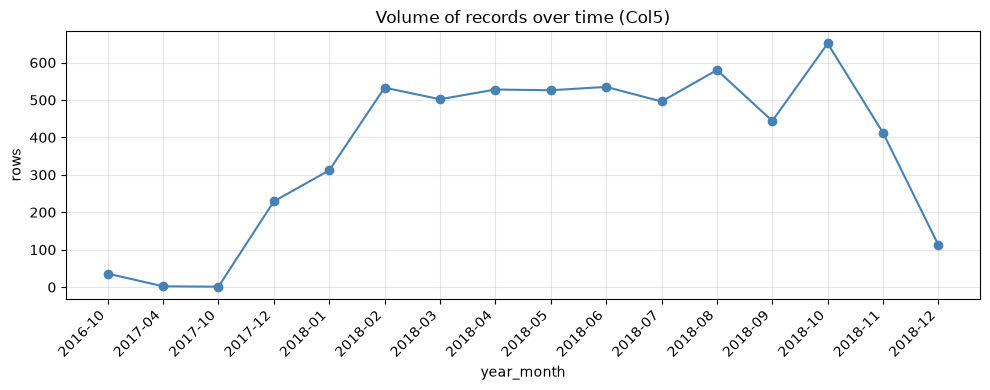

In [27]:
by_month = df.groupby(df['Col5'].dt.to_period('M').astype(str)).size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_month.index, by_month.values, marker='o', color='steelblue')
ax.set_title('Volume of records over time (Col5)')
ax.set_xlabel('year_month')
ax.set_ylabel('rows')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [44]:
by_month

Col5
2016-10     36
2017-04      2
2017-10      1
2017-12    229
2018-01    312
2018-02    533
2018-03    502
2018-04    528
2018-05    526
2018-06    535
2018-07    496
2018-08    580
2018-09    444
2018-10    651
2018-11    412
2018-12    112
dtype: int64

The dates run Oct-2016 to Dec-2018. A raw timestamp isn't something a classifier can use directly,
so **this is the one column that genuinely needs feature engineering**: I split it into `year`,
`month`, and `quarter`. Those capture seasonality and trend, which is usually where dates earn their
keep. **Decision: keep the engineered parts, drop the raw datetime for modelling.**

### Col6

In [28]:
print('Col6 distinct values:', df['Col6'].nunique())
print()
print('top 10:')
print(df['Col6'].value_counts().head(10))

Col6 distinct values: 196

top 10:
Col6
Word563 Word564 Word9 Word26       2165
Word563 Word580 Word581 Word232     506
Word563 Word366 Word562             438
Word563 Word575                     226
Word567 Word568 Word569 Word570     187
Word563 Word121 Word579             183
Word563 Word366 Word56 Word4        155
Word563 Word132 Word610             139
Word52 Word330 Word566              130
Word567 Word582 Word107             107
Name: count, dtype: int64


`Col6` is another categorical text column similar to `Col1` and `Col4`. Straight
ordinal encoding is fine here. 

### Col7

In [ ]:
print('Col7 distinct values:', df['Col7'].nunique())

whole = pd.DataFrame({
    'count': df['Col7'].value_counts(),
    'pct': (df['Col7'].value_counts(normalize=True) * 100).round(1),
})
print(whole)

Col7 distinct values: 4
       count   pct
Col7              
NoDoc   4635  78.6
Doc1    1108  18.8
Doc3     121   2.1
Doc2      35   0.6


`Col7` is the cleanest feature (`NoDoc`, `Doc1`, `Doc2`,`Doc3`). Low cardinality, no missing values. **Straight ordinal encode**

## Step 5 - Do the features actually relate to the target?

In [30]:
# does the document type (Col7) shift the class mix? row-normalised crosstab = 'given this Col7,
# what share of rows are each class'. if the rows differ a lot, Col7 carries signal.
ct = pd.crosstab(df['Col7'], df['label'], normalize='index') * 100
ct.round(1)

label,Category_1,Category_2,Category_3,Category_4,Category_5,Category_6
Col7,,,,,,
Doc1,96.3,3.6,0.0,0.0,0.1,0.0
Doc2,94.3,2.9,0.0,2.9,0.0,0.0
Doc3,78.5,12.4,0.0,9.1,0.0,0.0
NoDoc,86.7,12.4,0.5,0.1,0.0,0.3


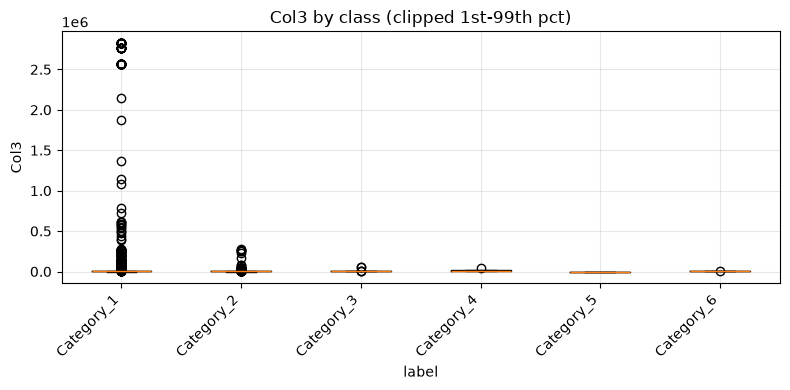

In [ ]:
# is Col3 (the numeric feature) distributed differently across classes? clipped again so the plot
# is readable. if the boxes sit at different levels, Col3 is useful.
lo, hi = df['Col3'].quantile([0.01, 0.99])
sub = df[(df['Col3'] >= lo) & (df['Col3'] <= hi)]

classes = sorted(sub['label'].unique())
data = [sub.loc[sub['label'] == c, 'Col3'].values for c in classes]

fig, ax = plt.subplots()
ax.boxplot(data)
ax.set_xticks(range(1, len(classes) + 1))
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_title('Col3 by class (clipped 1st-99th pct)')
ax.set_xlabel('label')
ax.set_ylabel('Col3')
plt.tight_layout()
plt.show()

# what it tells me 
# Col3 appears to be distributed differently across classes, suggesting it could be a useful feature for distinguishing between them.


In [ ]:
# and does the class mix drift over time? this also tells me whether a time-based split would be
# risky (if the target distribution changes across years).
year_mix = pd.crosstab(df['Col5_year'], df['label'], normalize='index') * 100
year_mix.round(1)
# what i understood is that the class distribution changes over the years, indicating potential drift.
# so the time-based split might be risky due to potential target distribution drift over the years.

label,Category_1,Category_2,Category_3,Category_4,Category_5,Category_6
Col5_year,,,,,,
2016,100.0,0.0,0.0,0.0,0.0,0.0
2017,77.2,22.0,0.0,0.9,0.0,0.0
2018,88.8,10.3,0.4,0.2,0.0,0.2


## Step 6 - Summary of decisions (what I'll actually build in the pipeline)

| Column | What it is | Missing | Decision |
|--------|------------|---------|----------|
| Col1 | categorical text (313) | none | ordinal encode, `handle_unknown='ignore'` |
| Col2 | near-unique / corrupted ID | none | **drop** (identifier, no generalisation) |
| Col3 | numeric, skewed, has outliers | none | keep; robust-scale if model needs it; no outlier deletion |
| Col4 | categorical text (2000) | 153 | fill `'missing'`, then ordinal encode |
| Col5 | date | none | **engineer** year / month / quarter, drop raw datetime |
| Col6 | categorical text (200) | none | ordinal encode |
| Col7 | clean categorical (4) | none | ordinal encode |
| label (H) | target, 6 classes | none | **normalise spelling variants**; handle heavy imbalance at modelling |

**Is feature engineering required?** Mostly light-touch:
- The only column that *needs* real engineering is `Col5` (date -> year/month/quarter).
- The rest is encoding + missing-value handling, not new features.
- The label needs cleaning.

**Two things that matter more than any single feature:**
1. The label was dirty - normalising it is non-negotiable.
2. The class imbalance is severe, so I'll evaluate with macro-F1 / balanced accuracy / confusion
   matrix and use `class_weight` (and consider bucketing the ultra-rare classes).

All of the above (drop Col2, fill Col4, engineer Col5, encode the rest, clean the label) goes into a
single scikit-learn pipeline next, so the exact same steps run automatically on any uploaded file.